In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mutual_info_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.ensemble import RandomForestClassifier

## Data Cleaning

In [3]:
df = pd.read_csv('../data/data.csv')
df.head().T

,0,1,2,3,4
Name,Christine Barker,Jacqueline Lewis,Shannon Church,Charles Jordan,Michael Rich
Age,31,55,78,58,18
Marital Status,Married,Married,Widowed,Divorced,Single
Education Level,Bachelor's Degree,High School,Master's Degree,Master's Degree,High School
Number of Children,2,1,1,3,0
Smoking Status,Non-smoker,Non-smoker,Non-smoker,Non-smoker,Non-smoker
Physical Activity Level,Active,Sedentary,Sedentary,Moderate,Sedentary
Employment Status,Unemployed,Employed,Employed,Unemployed,Unemployed
Income,26265.67,42710.36,125332.79,9992.78,8595.08
Alcohol Consumption,Moderate,High,Low,Moderate,Low


In [4]:
df.shape

(413768, 16)

In [5]:
# rename all columns so all columns have uniform variable naming style
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [6]:
# collect all columns whose data types are strings
columns_list = list(df.dtypes[df.dtypes == 'object'].index)
columns_list

['name',
 'marital_status',
 'education_level',
 'smoking_status',
 'physical_activity_level',
 'employment_status',
 'alcohol_consumption',
 'dietary_habits',
 'sleep_patterns',
 'history_of_mental_illness',
 'history_of_substance_abuse',
 'family_history_of_depression',
 'chronic_medical_conditions']

In [7]:
# rename data in each column to have uniform variable naming style
for col in columns_list:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [8]:
# Map target variable values to binary value
target_variable = 'chronic_medical_conditions'
df[target_variable] = df[target_variable].map({'yes': 1, 'no': 0})

In [9]:
df.head().T

,0,1,2,3,4
name,christine_barker,jacqueline_lewis,shannon_church,charles_jordan,michael_rich
age,31,55,78,58,18
marital_status,married,married,widowed,divorced,single
education_level,bachelor's_degree,high_school,master's_degree,master's_degree,high_school
number_of_children,2,1,1,3,0
smoking_status,non-smoker,non-smoker,non-smoker,non-smoker,non-smoker
physical_activity_level,active,sedentary,sedentary,moderate,sedentary
employment_status,unemployed,employed,employed,unemployed,unemployed
income,26265.67,42710.36,125332.79,9992.78,8595.08
alcohol_consumption,moderate,high,low,moderate,low


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413768 entries, 0 to 413767
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   name                          413768 non-null  object 
 1   age                           413768 non-null  int64  
 2   marital_status                413768 non-null  object 
 3   education_level               413768 non-null  object 
 4   number_of_children            413768 non-null  int64  
 5   smoking_status                413768 non-null  object 
 6   physical_activity_level       413768 non-null  object 
 7   employment_status             413768 non-null  object 
 8   income                        413768 non-null  float64
 9   alcohol_consumption           413768 non-null  object 
 10  dietary_habits                413768 non-null  object 
 11  sleep_patterns                413768 non-null  object 
 12  history_of_mental_illness     413768 non-nul

In [11]:
# Check for missing values
df.isnull().sum()

name                            0
age                             0
marital_status                  0
education_level                 0
number_of_children              0
smoking_status                  0
physical_activity_level         0
employment_status               0
income                          0
alcohol_consumption             0
dietary_habits                  0
sleep_patterns                  0
history_of_mental_illness       0
history_of_substance_abuse      0
family_history_of_depression    0
chronic_medical_conditions      0
dtype: int64

In [12]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [13]:
# drop name column. it's not needed
del df['name']

## Exploratory Data Analysis

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,413768.0,49.000713,18.158759,18.00,33.00,49.000,65.0,80.00
number_of_children,413768.0,1.298972,1.237054,0.00,0.00,1.000,2.0,4.00
income,413768.0,50661.707971,40624.100565,0.41,21001.03,37520.135,76616.3,209995.22
chronic_medical_conditions,413768.0,0.329187,0.469919,0.00,0.00,0.000,1.0,1.00


In [15]:
# Look at numerical and categorical fetures
categorical_features = list(df.dtypes[df.dtypes == 'object'].index)
numerical_features = list(df.dtypes[df.dtypes != 'object'].index)

# From the output below, numerical_fetures includes chronic_medical_conditions variable which is our target therefore the tagert variable has to be removed
features = (categorical_features + numerical_features)
features.remove(target_variable)

print('Categorical Columns')
print(categorical_features)
print()
print('Numerical Columns')
print(numerical_features)
print()
print('Features')
print(features)

Categorical Columns
['marital_status', 'education_level', 'smoking_status', 'physical_activity_level', 'employment_status', 'alcohol_consumption', 'dietary_habits', 'sleep_patterns', 'history_of_mental_illness', 'history_of_substance_abuse', 'family_history_of_depression']

Numerical Columns
['age', 'number_of_children', 'income', 'chronic_medical_conditions']

Features
['marital_status', 'education_level', 'smoking_status', 'physical_activity_level', 'employment_status', 'alcohol_consumption', 'dietary_habits', 'sleep_patterns', 'history_of_mental_illness', 'history_of_substance_abuse', 'family_history_of_depression', 'age', 'number_of_children', 'income']


In [16]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:10])
    print(df[col].nunique())
    print()

age
[31 55 78 58 18 20 60 50 77 70]
63

marital_status
['married' 'widowed' 'divorced' 'single']
4

education_level
["bachelor's_degree" 'high_school' "master's_degree" 'associate_degree'
 'phd']
5

number_of_children
[2 1 3 0 4]
5

smoking_status
['non-smoker' 'former' 'current']
3

physical_activity_level
['active' 'sedentary' 'moderate']
3

employment_status
['unemployed' 'employed']
2

income
[ 26265.67  42710.36 125332.79   9992.78   8595.08  44448.91  22565.47
  39608.18  93360.07  77597.84]
405282

alcohol_consumption
['moderate' 'high' 'low']
3

dietary_habits
['moderate' 'unhealthy' 'healthy']
3

sleep_patterns
['fair' 'good' 'poor']
3

history_of_mental_illness
['yes' 'no']
2

history_of_substance_abuse
['no' 'yes']
2

family_history_of_depression
['yes' 'no']
2

chronic_medical_conditions
[1 0]
2



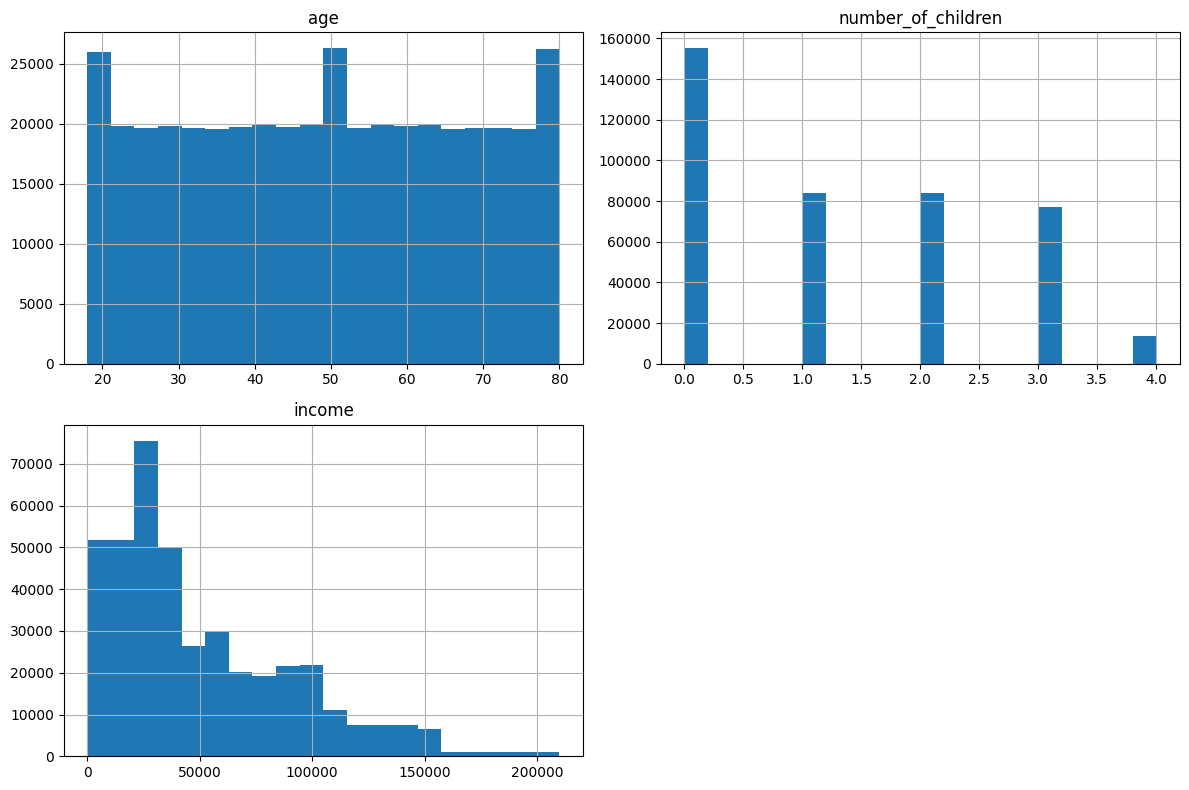

In [17]:
# Select all numeric columns except 'chronic_medical_conditions'. # The column 'chronic_medical_conditions' is the target variable and has binary values hence its histogram is not needed since we are trying to solve a classification problem.
cols_to_plot = df.drop(columns=['chronic_medical_conditions'])

cols_to_plot.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

In [18]:
# evaluate class balance for the target variable
df.chronic_medical_conditions.value_counts(normalize=True)

chronic_medical_conditions
0    0.670813
1    0.329187
Name: proportion, dtype: float64

## Feature Importance

In [19]:
def mutual_info_default_score(series):
    return mutual_info_score(series, df.chronic_medical_conditions)

In [20]:
mi = df[categorical_features].apply(mutual_info_default_score)
mi.sort_values(ascending=False)

smoking_status                  0.001373
employment_status               0.000895
physical_activity_level         0.000639
sleep_patterns                  0.000149
dietary_habits                  0.000137
alcohol_consumption             0.000128
marital_status                  0.000081
history_of_mental_illness       0.000018
education_level                 0.000006
history_of_substance_abuse      0.000005
family_history_of_depression    0.000003
dtype: float64

In [21]:
df[numerical_features].corrwith(df.chronic_medical_conditions).abs()

age                           0.017625
number_of_children            0.006997
income                        0.028427
chronic_medical_conditions    1.000000
dtype: float64

## Data Split

After repeated kernel crash during parameter tuning for random forest, I realized the dataset (248k rows) is too large to fit above 100 tree random forest in a remote environment (code space). Memory usage grows with number of trees. your RAM usage spikes massively. Linux detects this and kills the Python process (kernel crash). The cut down of the data into smaller size down in the following cell below is not necessary if the computation resources are available.


In [36]:
df_cut_down, df_remaining = train_test_split(df, test_size=0.925, random_state=42)
print(df_cut_down.shape,  df_remaining.shape, df.shape)

(31032, 15) (382736, 15) (413768, 15)


In [37]:
# Split the data set using 60 20 20 split
df_full_train, df_test = train_test_split(df_cut_down, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

In [38]:
print(df_train.shape, df_val.shape, df_test.shape)

(18618, 15) (6207, 15) (6207, 15)


In [39]:
# reset index of the dfs resulting from the split
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [40]:
# collect the targets for each of the training, validation and test datasets
y_train = df_train.chronic_medical_conditions.values
y_val = df_val.chronic_medical_conditions.values
y_test = df_test.chronic_medical_conditions.values

In [41]:
# remove the targets from each of the training, validation and test datasets so that the dataframe only contains the features
del df_train['chronic_medical_conditions']
del df_val['chronic_medical_conditions']
del df_test['chronic_medical_conditions']

## One Hot Encoding

In [42]:
dv = DictVectorizer(sparse=False)

X_train_dict = df_train.to_dict(orient='records')
X_train = dv.fit_transform(X_train_dict)

X_val_dict = df_val.to_dict(orient='records')
X_val = dv.transform(X_val_dict)

X_test_dict = df_test.to_dict(orient='records')
X_test = dv.transform(X_test_dict)

## Training Logistic Regression

In [43]:
# Training logistic regression with Scikit-Learn

model = LogisticRegression(solver='liblinear', C=0.00000001, max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1e-08
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`m

In [44]:
y_pred = model.predict_proba(X_val)[:, 1]
y_pred

array([0.41004455, 0.40834082, 0.46522065, ..., 0.49195409, 0.45900638,
       0.36536559], shape=(6207,))

In [45]:
auc  = roc_auc_score(y_val, y_pred)

print(f'The AUC of this model on the validation dataset is {round(auc, 4)}')

The AUC of this model on the validation dataset is 0.5186


## Parameter tuning to find best C for logistic Regresion

In [46]:
for C in [0.00000001, 0.0000001, 0.000001, 0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]:


    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)

    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:, 1]

    auc  = roc_auc_score(y_val, y_pred)

    print('%4s -> %.3f' % (C, auc))


1e-08 -> 0.519
1e-07 -> 0.521
1e-06 -> 0.520
1e-06 -> 0.520
1e-05 -> 0.518
0.0001 -> 0.517
0.001 -> 0.517
0.01 -> 0.517
 0.1 -> 0.517
   1 -> 0.517
  10 -> 0.517
 100 -> 0.517
1000 -> 0.517
10000 -> 0.517
100000 -> 0.517


0.00000001 seem to be the best value for C

## Training Decision Tree

In [47]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred = dt.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.5073557644800181

## Deision Tree Parameter Tuning

In [48]:
depths = [1, 2, 3, 4, 5, 6, 10, 15, 20, None]

for depth in depths: 
    dt = DecisionTreeClassifier(max_depth=depth)
    dt.fit(X_train, y_train)
    
    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    
    print('%4s -> %.6f' % (depth, auc))

   1 -> 0.517918
   2 -> 0.529250
   3 -> 0.534376
   4 -> 0.538745
   5 -> 0.525454
   6 -> 0.532573
  10 -> 0.517894
  15 -> 0.495384
  20 -> 0.502155
None -> 0.502620


4 seems to be the best value for max_depth

## max_depth and min_samples_leaf tuning for the decision tree

In [49]:
scores = []

for depth in [4, 5, 6]:
    for s in [1, 5, 10, 15, 20, 500, 100, 200]:
        dt = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=s)
        dt.fit(X_train, y_train)

        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        
        scores.append((depth, s, auc))

columns = ['max_depth', 'min_samples_leaf', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

In [50]:
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns=['max_depth'], values=['auc'])
df_scores_pivot.round(3)

auc              
max_depth             4      5      6
min_samples_leaf                     
1                 0.539  0.526  0.533
5                 0.539  0.526  0.534
10                0.534  0.524  0.534
15                0.534  0.525  0.535
20                0.534  0.525  0.534
100               0.537  0.530  0.527
200               0.538  0.530  0.531
500               0.538  0.534  0.534

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

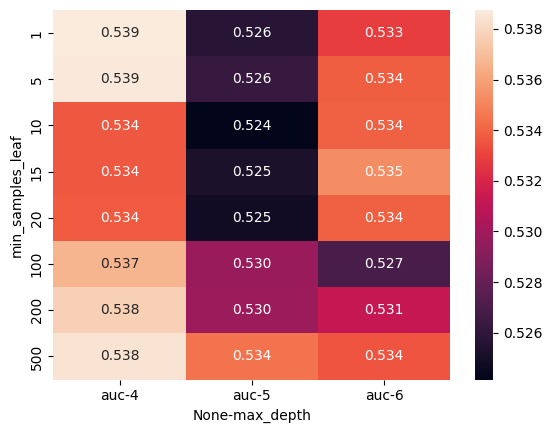

In [53]:
sns.heatmap(df_scores_pivot, annot=True, fmt=".3f")

1 seems to be the best value for min_samples_leaf

## Final decision tree model parameters

In [65]:
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=1)
dt.fit(X_train, y_train)

y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
auc

0.5387454297773824

## Training Random Forest

In [66]:
rf = RandomForestClassifier(n_estimators=10, random_state=1)
rf.fit(X_train, y_train)

y_pred = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)


0.49840548050273625

## Parameter tuninng for random forest

In [67]:
scores = []
for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    
    scores.append((n, auc))

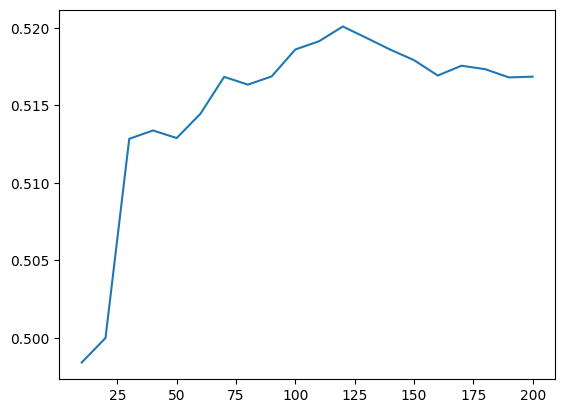

In [68]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])
plt.plot(df_scores.n_estimators, df_scores.auc)

Best value for n_estimator is 90

In [69]:
scores = []

for d in [5, 10, 15]:
    for n in range(10, 101, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=d,
                                    random_state=1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((d, n, auc))

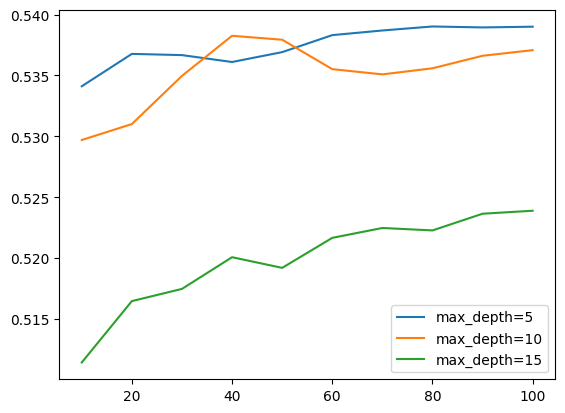

In [70]:
columns = ['max_depth', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
for d in [5, 10, 15]:
    df_subset = df_scores[df_scores.max_depth == d]
    
    plt.plot(df_subset.n_estimators, df_subset.auc,
             label='max_depth=%d' % d)

plt.legend()

Best value of max_depth is 5

In [71]:
max_depth = 10

scores = []

for s in [1, 3, 5, 10, 50]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=max_depth,
                                    min_samples_leaf=s,
                                    random_state=1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((s, n, auc))

In [72]:
columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

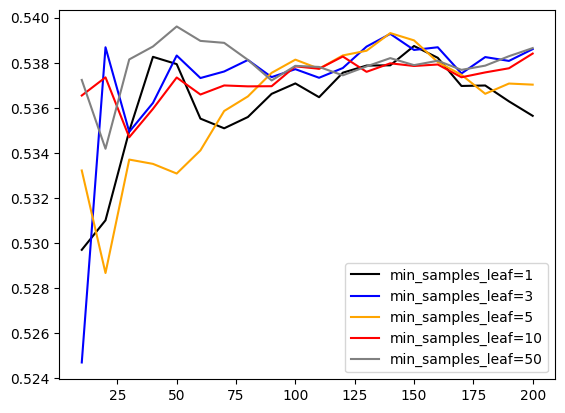

In [73]:
colors = ['black', 'blue', 'orange', 'red', 'grey']
values = [1, 3, 5, 10, 50]

for s, col in zip(values, colors):
    df_subset = df_scores[df_scores.min_samples_leaf == s]
    
    plt.plot(df_subset.n_estimators, df_subset.auc,
             color=col,
             label='min_samples_leaf=%d' % s)

plt.legend()

Best value for min_sample_leaf is 3

## Final Random Forest Model Parameters

In [104]:
rf = RandomForestClassifier(n_estimators=90,
                            max_depth=5,
                            min_samples_leaf=3,
                            random_state=1)
rf.fit(X_train, y_train)

y_pred = rf.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
auc

0.5387167261913165

## Training XGBoost

In [105]:
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [144]:
xgb_params = {
    'eta': 0.1, 
    'max_depth': 3,
    'min_child_weight': 1,
    
    'objective': 'binary:logistic',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=10)

In [145]:
y_pred = model.predict(dval)

In [146]:
roc_auc_score(y_val, y_pred)


0.5389156514537661

Tree models including logistic regression, decsion trees, random forest and XGBoost were trained using AUC-ROC as the performance metric, the best model is XGBoost since it get the highest AUC-ROC score